# S1.2: screen простых topology/contact repair

Этот notebook **не запускает регистрацию и не строит парные анатомические карты**. Он читает воспроизводимый post-hoc batch на пяти quarantined S1.1 fields без expert landmarks. Цель — проверить класс `Gaussian repair + algebraic normal coupling`, а не выбрать очередные параметры по результату.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

candidate = Path.cwd().resolve()
REPO_ROOT = next(
    (path for path in (candidate, *candidate.parents) if (path / "pyproject.toml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Не найден корень репозитория")

RESULTS = REPO_ROOT / "results/sliding_s12_heuristic_screen_v1"
INPUT_BATCH = REPO_ROOT / "results/sliding_s11_real_development_v1"
manifest_path = RESULTS / "manifest.json"
summary_path = RESULTS / "summary.csv"
if not manifest_path.is_file() or not summary_path.is_file():
    raise RuntimeError(
        "Нет S1.2 heuristic screen batch. Выполните: "
        "breathgeom registration sliding-s12-heuristic-screen"
    )

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
summary = pd.read_csv(summary_path)
screen_config_path = REPO_ROOT / "configs/sliding_s12_heuristic_screen_v1.json"
gate_config_path = REPO_ROOT / "configs/sliding_s11_real_development_gate.json"
screen_config = json.loads(screen_config_path.read_text(encoding="utf-8"))
gate_config = json.loads(gate_config_path.read_text(encoding="utf-8"))
variant_order = [variant["name"] for variant in screen_config["variants"]]
summary.head()

,dataset_id,subject_id,screen_version,variant,transform_direction,coordinate_basis,expert_landmarks_loaded,measurement_eligible,lung_smoothing_sigma_mm,lung_scale,...,interface_tangential_slip_median_mm,interface_tangential_slip_p95_mm,lung_displacement_p99_mm,body_displacement_p99_mm,correspondence_pass,topology_pass,contact_pass,screen_criteria_pass,screen_reasons,elapsed_s
0,learn2reg_lungct,LungCT_0004,s1.2-heuristic-screen-v1,raw_initial_uncoupled,fixed-expiration_to_moving-inspiration,local-zero-origin-RAS+_mm,False,False,0.0,1.0,...,5.261086,13.281712,14.452187,38.104820,True,False,False,False,lung_folding;interface_normal_mismatch_p95,2.495809
1,learn2reg_lungct,LungCT_0004,s1.2-heuristic-screen-v1,gaussian3_scale0.9_uncoupled,fixed-expiration_to_moving-inspiration,local-zero-origin-RAS+_mm,False,False,3.0,0.9,...,4.727841,12.102075,12.866299,38.104820,True,True,False,False,interface_normal_mismatch_p95,3.080552
2,learn2reg_lungct,LungCT_0004,s1.2-heuristic-screen-v1,gaussian3_scale0.9_narrow_body_normal,fixed-expiration_to_moving-inspiration,local-zero-origin-RAS+_mm,False,False,3.0,0.9,...,4.727840,12.102075,13.129014,38.104820,True,False,True,False,lung_folding,3.279708
3,learn2reg_lungct,LungCT_0004,s1.2-heuristic-screen-v1,gaussian3_scale0.9_wide_symmetric_normal,fixed-expiration_to_moving-inspiration,local-zero-origin-RAS+_mm,False,False,3.0,0.9,...,4.718671,11.988202,12.699553,37.477226,True,False,True,False,lung_folding;body_folding,3.430645
4,learn2reg_lungct,LungCT_0005,s1.2-heuristic-screen-v1,raw_initial_uncoupled,fixed-expiration_to_moving-inspiration,local-zero-origin-RAS+_mm,False,False,0.0,1.0,...,7.614604,19.741025,24.677837,31.572956,False,False,False,False,lung_fov_surface_p95;keypoint_tre_p95;lung_fol...,2.510057


## Provenance и disposition

Проверяются batch/config/summary и все пять входных NPZ. Результат остаётся development-only; отсутствие `LungCT_0029` должно быть явно зафиксировано, а не забыто.

In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


checks = {
    "input batch manifest": sha256(INPUT_BATCH / "manifest.json")
    == manifest["input_batch_manifest"]["sha256"],
    "screen config": sha256(screen_config_path) == manifest["screen_config"]["sha256"],
    "gate config": sha256(gate_config_path) == manifest["gate_config"]["sha256"],
    "summary": sha256(summary_path) == manifest["summary_sha256"],
    "input fields": all(
        sha256(INPUT_BATCH / relative) == digest
        for relative, digest in manifest["verified_input_field_sha256"].items()
    ),
    "expert landmarks unused": manifest["expert_landmarks_used"] is False,
    "batch not measurement eligible": manifest["measurement_eligible"] is False,
    "rows not measurement eligible": not summary["measurement_eligible"]
    .map(lambda value: str(value).lower() == "true")
    .any(),
    "five subjects": summary["subject_id"].nunique() == 5,
    "twenty rows": len(summary) == 20,
    "expected missing 0029": manifest["expected_missing_subject_ids"] == ["LungCT_0029"],
    "no batch failures": manifest["failures"] == [],
}
provenance_table = pd.DataFrame({"check": list(checks), "pass": list(checks.values())})
display(provenance_table)
if not all(checks.values()):
    raise RuntimeError("Нарушена целостность или disposition screen-артефактов")

display(
    pd.DataFrame(
        {
            "field": [
                "code_version",
                "screen_version",
                "subjects",
                "records",
                "batch_elapsed_s",
                "simple_heuristic_class_viable",
            ],
            "value": [
                manifest["code_version"],
                manifest["screen_version"],
                manifest["subject_count"],
                manifest["record_count"],
                round(manifest["batch_elapsed_s"], 1),
                manifest["simple_heuristic_class_viable"],
            ],
        }
    )
)

,check,pass
0,input batch manifest,True
1,screen config,True
2,gate config,True
3,summary,True
4,input fields,True
5,expert landmarks unused,True
6,batch not measurement eligible,True
7,rows not measurement eligible,True
8,five subjects,True
9,twenty rows,True


,field,value
0,code_version,a582258dd8f06a880a79d261e134f582e60d54e9
1,screen_version,s1.2-heuristic-screen-v1
2,subjects,5
3,records,20
4,batch_elapsed_s,194.4
5,simple_heuristic_class_viable,False


## Раздельные оси качества

`screen_criteria_pass` требует одновременно correspondence, topology и contact. Нулевой общий PASS может иметь разные причины, поэтому компоненты нельзя сворачивать в один Dice.

In [3]:
component_counts = (
    summary.groupby("variant")[[
        "correspondence_pass",
        "topology_pass",
        "contact_pass",
        "screen_criteria_pass",
    ]]
    .sum()
    .reindex(variant_order)
    .astype(int)
)
component_counts.columns = [
    "correspondence /5",
    "topology /5",
    "contact /5",
    "all criteria /5",
]
display(component_counts)

median_metrics = (
    summary.groupby("variant")[[
        "keypoint_tre_mean_mm",
        "keypoint_tre_p95_mm",
        "lung_fov_surface_p95_mm",
        "lung_jacobian_p01",
        "lung_nonpositive_jacobian_fraction",
        "body_nonpositive_jacobian_fraction",
        "interface_normal_mismatch_p95_mm",
    ]]
    .median()
    .reindex(variant_order)
)
median_metrics["lung_nonpositive_jacobian_percent"] = (
    100 * median_metrics.pop("lung_nonpositive_jacobian_fraction")
)
median_metrics["body_nonpositive_jacobian_percent"] = (
    100 * median_metrics.pop("body_nonpositive_jacobian_fraction")
)
display(median_metrics.round(3))

,correspondence /5,topology /5,contact /5,all criteria /5
variant,,,,
raw_initial_uncoupled,2,0,0,0
gaussian3_scale0.9_uncoupled,2,5,0,0
gaussian3_scale0.9_narrow_body_normal,2,0,5,0
gaussian3_scale0.9_wide_symmetric_normal,2,0,5,0


,keypoint_tre_mean_mm,keypoint_tre_p95_mm,lung_fov_surface_p95_mm,lung_jacobian_p01,interface_normal_mismatch_p95_mm,lung_nonpositive_jacobian_percent,body_nonpositive_jacobian_percent
variant,,,,,,,
raw_initial_uncoupled,1.698,6.505,5.250,0.240,6.899,0.194,0.000
gaussian3_scale0.9_uncoupled,2.571,7.170,5.420,0.613,6.512,0.000,0.000
gaussian3_scale0.9_narrow_body_normal,2.617,8.854,5.130,0.070,0.000,0.841,0.000
gaussian3_scale0.9_wide_symmetric_normal,2.782,9.137,6.103,0.443,0.000,0.068,0.042


## Что меняет каждый вариант

Gaussian repair сохраняет локальное поле и устраняет folding лёгкого, но не обеспечивает contact. Оба algebraic coupling зануляют normal mismatch, одновременно возвращая folding.

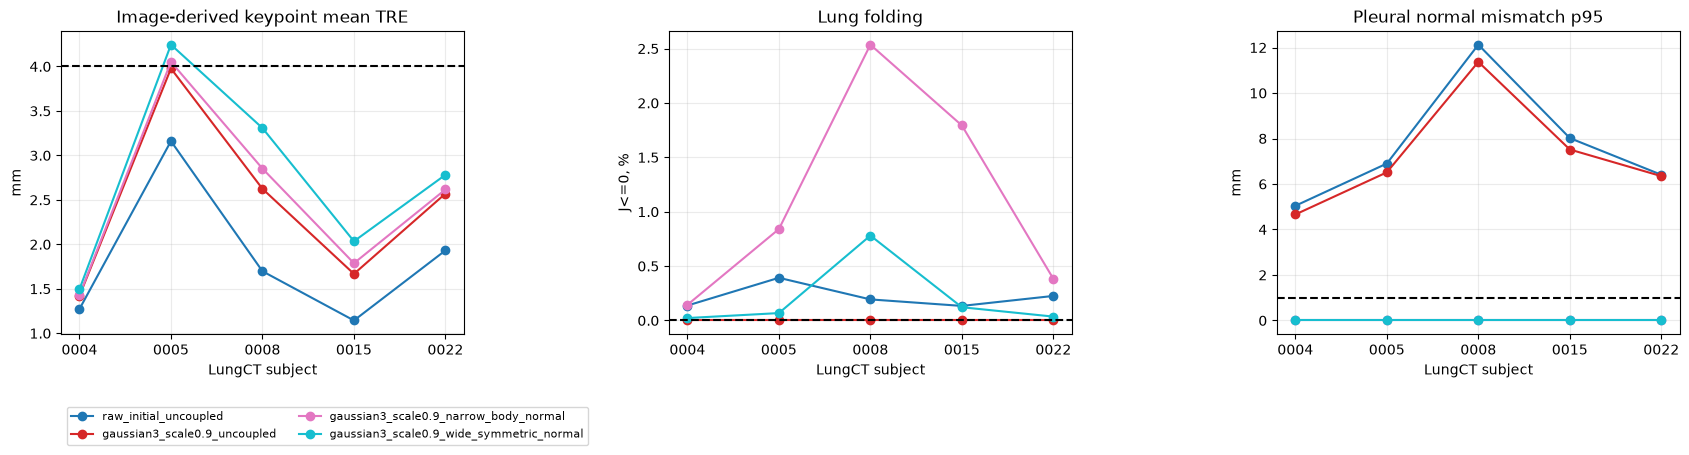

In [4]:
subjects = list(summary["subject_id"].drop_duplicates())
short_subjects = [value.replace("LungCT_", "") for value in subjects]
colors = plt.cm.tab10(np.linspace(0, 1, len(variant_order)))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

for variant, color in zip(variant_order, colors, strict=True):
    rows = summary.set_index(["variant", "subject_id"]).loc[variant].reindex(subjects)
    axes[0].plot(short_subjects, rows["keypoint_tre_mean_mm"], marker="o", label=variant, color=color)
    axes[1].plot(
        short_subjects,
        100 * rows["lung_nonpositive_jacobian_fraction"],
        marker="o",
        label=variant,
        color=color,
    )
    axes[2].plot(
        short_subjects,
        rows["interface_normal_mismatch_p95_mm"],
        marker="o",
        label=variant,
        color=color,
    )

axes[0].axhline(gate_config["thresholds"]["keypoint_tre_after_mean_max_mm"], color="black", ls="--")
axes[0].set_title("Image-derived keypoint mean TRE")
axes[0].set_ylabel("mm")
axes[1].axhline(0, color="black", ls="--")
axes[1].set_title("Lung folding")
axes[1].set_ylabel("J<=0, %")
axes[2].axhline(gate_config["thresholds"]["interface_normal_mismatch_p95_max_mm"], color="black", ls="--")
axes[2].set_title("Pleural normal mismatch p95")
axes[2].set_ylabel("mm")
for axis in axes:
    axis.set_xlabel("LungCT subject")
    axis.grid(alpha=0.25)
axes[0].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2)
fig.tight_layout()
plt.show()

## Причины отказа по субъектам

`LungCT_0005` остаётся отдельной проблемой исходной регистрации: даже topology-safe uncoupled repair не проходит surface p95 и keypoint p95. Значит новый contact formulation сам по себе недостаточен.

In [5]:
reason_rows = []
for row in summary.itertuples(index=False):
    reasons = str(row.screen_reasons).split(";") if str(row.screen_reasons) else []
    for reason in reasons:
        reason_rows.append({"subject_id": row.subject_id, "variant": row.variant, "reason": reason})
reason_table = pd.DataFrame(reason_rows)
reason_counts = (
    reason_table.groupby(["variant", "reason"]).size().unstack(fill_value=0).reindex(variant_order)
)
display(reason_counts)

focus_0005 = summary.loc[
    summary["subject_id"] == "LungCT_0005",
    [
        "variant",
        "lung_fov_surface_p95_mm",
        "keypoint_tre_mean_mm",
        "keypoint_tre_p95_mm",
        "lung_nonpositive_jacobian_fraction",
        "interface_normal_mismatch_p95_mm",
        "screen_reasons",
    ],
].set_index("variant").reindex(variant_order)
display(focus_0005)

reason,body_folding,interface_normal_mismatch_p95,keypoint_tre_mean,keypoint_tre_p95,lung_folding,lung_fov_surface_p95,lung_jacobian_p01
variant,,,,,,,
raw_initial_uncoupled,0,5,0,1,5,3,0
gaussian3_scale0.9_uncoupled,0,5,0,1,0,3,0
gaussian3_scale0.9_narrow_body_normal,0,0,1,1,5,3,3
gaussian3_scale0.9_wide_symmetric_normal,5,0,1,2,5,3,0


,lung_fov_surface_p95_mm,keypoint_tre_mean_mm,keypoint_tre_p95_mm,lung_nonpositive_jacobian_fraction,interface_normal_mismatch_p95_mm,screen_reasons
variant,,,,,,
raw_initial_uncoupled,7.000000,3.160656,14.442279,0.003924,6.899209e+00,lung_fov_surface_p95;keypoint_tre_p95;lung_fol...
gaussian3_scale0.9_uncoupled,7.322909,3.977708,14.780780,0.000000,6.512275e+00,lung_fov_surface_p95;keypoint_tre_p95;interfac...
gaussian3_scale0.9_narrow_body_normal,6.786936,4.051895,15.077394,0.008406,3.086946e-07,lung_fov_surface_p95;keypoint_tre_mean;keypoin...
gaussian3_scale0.9_wide_symmetric_normal,6.349213,4.244984,15.493360,0.000680,4.155556e-07,lung_fov_surface_p95;keypoint_tre_mean;keypoin...


## Решение о следующем классе S1.2

In [6]:
uncoupled = summary[summary["variant"] == "gaussian3_scale0.9_uncoupled"]
coupled = summary[summary["couple_normal"]]
if (
    manifest["simple_heuristic_class_viable"]
    or int(uncoupled["topology_pass"].sum()) != 5
    or int(coupled["screen_criteria_pass"].sum()) != 0
):
    raise RuntimeError("Screen verdict не соответствует frozen правилу перехода")

display(
    Markdown(
        "**КЛАСС ОТВЕРГНУТ: coupled 0/5.** Gaussian repair дал topology 5/5, "
        "но contact 0/5; оба algebraic normal coupling дали contact 5/5, но topology "
        "0/5. Дальнейший post-hoc подбор `sigma/taper` прекращается. Следующий кандидат "
        "должен совместно оптимизировать отдельные topology-preserving lung/body "
        "параметризации с ограничением только нормальной компоненты на интерфейсе и "
        "сохранять локальную tangential residual. Дополнительно нужно улучшить исходную "
        "image registration для `LungCT_0005`. Это всё ещё не открывает expert Gate 1L "
        "и не разрешает парные карты толщины/формы."
    )
)

**КЛАСС ОТВЕРГНУТ: coupled 0/5.** Gaussian repair дал topology 5/5, но contact 0/5; оба algebraic normal coupling дали contact 5/5, но topology 0/5. Дальнейший post-hoc подбор `sigma/taper` прекращается. Следующий кандидат должен совместно оптимизировать отдельные topology-preserving lung/body параметризации с ограничением только нормальной компоненты на интерфейсе и сохранять локальную tangential residual. Дополнительно нужно улучшить исходную image registration для `LungCT_0005`. Это всё ещё не открывает expert Gate 1L и не разрешает парные карты толщины/формы.